
# 🧮 Day 2 — How LLMs Work: Probability, Sampling & Prompts

<a href="https://colab.research.google.com/github/Tulane-CMPS-1010-AI-Systems/course-materials/blob/main/lectures/02-probability_lecture.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

📘 **Theme:** Understanding LLMs as probabilistic systems — linking mathematical intuition to model behavior and creative control.

---

### **Learning Objectives**
By the end of this week, you will be able to:
1. Write the probabilistic formulation of an LLM.
2. Explain how maximum likelihood training shapes model behavior.
3. Describe how temperature and entropy control randomness.
4. Analyze how prompts condition outputs.
5. Apply basic prompt engineering patterns (chain-of-thought, few-shot, role-playing).
6. Relate math intuition to real-world UX reliability.


In [ ]:
# @title Setup (Run this first)
!git clone --depth 1 -q https://github.com/Tulane-CMPS-1010-AI-Systems/course-materials.git
import sys; sys.path.append('./course-materials')
from IPython.display import Markdown
from course_utils import lab2_setup, show_mermaid

lab2_setup()

🔧 Setting up your environment...
  → Installing core packages...
installing mermaid-python
  → Setting random seed for reproducible results...
  → Checking API key...
🔑 Enter your OpenAI API key.
   (It will only be stored in this Colab runtime - it's safe!)
   Get your key from: https://platform.openai.com/api-keys
OpenAI API key: ··········
✅ API key set.
  → Adding course files to path...
✅ Setup complete!
✅ lab2_setup complete — helper function loaded.



## 🧩 A Simple Model of an LLM
---
**Guiding Question:**  
> What does it mean to say that an LLM “predicts the next token”?  
> How do probabilities create creativity *and* hallucinations?



### 🔢 The LLM as a Probability Model

A language model defines the probability of a sequence as:

$$
P(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} P(x_t \mid x_{1:t-1})
$$

Each word is drawn from a conditional distribution based on what came before.


In [7]:
import numpy as np

tokens = ["is", "was", "will be", "seems"]
probs = np.array([0.65, 0.20, 0.10, 0.05])

for i in range(5):
    print(f"Sample {i+1}: {np.random.choice(tokens, p=probs)}")

Sample 1: was
Sample 2: is
Sample 3: is
Sample 4: is
Sample 5: is



### 🧮 Maximum Likelihood Training

Training seeks parameters $\theta$ that make real text more probable:

$$
\theta^* = \arg\max_{\theta} \sum_{t=1}^{T} \log P_\theta(x_t \mid x_{1:t-1})
$$

Taking the log makes it easier to optimize (turns multiplication into addition).

In simple terms: the model rewards itself when it correctly predicts real text.


In [11]:
true_next = "mat"
pred_probs = {"mat": 0.7, "rug": 0.2, "dog": 0.1}

import numpy as np
print("True token:", true_next)
print("Predicted probabilities:", pred_probs)
print("Log-likelihood contribution:", np.log(pred_probs[true_next]))

True token: mat
Predicted probabilities: {'mat': 0.7, 'rug': 0.2, 'dog': 0.1}
Log-likelihood contribution: -0.35667494393873245



### 🎭 Why Likelihood ≠ Truth

The model optimizes *linguistic probability*, not *factual accuracy*:

$$
P(\text{"2 + 2 = 4"}) \approx 0.99, \quad P(\text{"2 + 2 = 5"}) \approx 0.01
$$

For unseen prompts, it predicts what **sounds** likely — even if false.

> **Hallucination:** high $P(\text{text}|\text{context})$, low $P(\text{truth}|\text{world})$.



### 🧩 Unifying Diagram v1 — Adding Training Data Distribution

Everything the model knows comes from its **training data distribution**, which shapes its probabilities.



In [12]:
# @title Updated LLM diagram with training data

show_mermaid(
    """
    graph TD
    subgraph User Interaction
    U["👤 Users<br/>Queries / Inputs"]:::user --> IH["Input Handling<br/>• Formatting<br/>• Validation<br/>• Safety Filters"]:::process
    end

    subgraph Prompt & Control
    IH --> PC("Prompt / Control<br/>• Instructions<br/>• Examples<br/>• Constraints<br/>• Temperature & Sampling"):::control
    end

    subgraph Tools & Augmentation
    PC --> TF{"Tools / Functions<br/>• External APIs"}:::tool
    PC --> RAG{"Retrieval (RAG)<br/>• Embeddings<br/>• Vector Store<br/>• Top-k Search"}:::tool
    end

    subgraph Core LLM
    TF --> LLM["Core LLM<br/>• Next-token probabilities<br/>• Sampling<br/>• Fine-tuned weights"]:::model
    RAG --> LLM
    PC --> LLM
    end

    subgraph Model Training
    D["📚 Training Data Distribution<br/>• Text corpus<br/>• Domain sources<br/>• Biases"]:::data --> LLM
    end

    subgraph Output & Monitoring
    LLM --> OP["Output Processing<br/>• Formatting<br/>• Citations<br/>• Refusals<br/>• Trust Signals"]:::output --> O("Final Output"):::output
    O --> LM["Logging & Monitoring<br/>• Prompts & Responses<br/>• Metrics<br/>• Drift Detection"]:::monitor
    end

    classDef user fill:#d1e7dd,stroke:#333,stroke-width:1px;
    classDef process fill:#e2e3e5,stroke:#333,stroke-width:1px;
    classDef control fill:#cfe2ff,stroke:#333,stroke-width:1px;
    classDef tool fill:#fff3cd,stroke:#333,stroke-width:1px;
    classDef model fill:#f8d7da,stroke:#333,stroke-width:1px;
    classDef output fill:#e9ecef,stroke:#333,stroke-width:1px;
    classDef monitor fill:#fefefe,stroke:#333,stroke-width:1px;
    classDef data fill:#fde2e4,stroke:#333,stroke-width:1px;
    """
)

## More details on training

<img src="https://github.com/tulane-cmps6730/main/blob/main/lec/chat/figs/instructgptpaper.png?raw=1" width=60%/>

https://arxiv.org/pdf/2203.02155.pdf

<img src="https://github.com/tulane-cmps6730/main/blob/main/lec/chat/figs/instructgpt.png?raw=1" width=90%/>




- **Pretraining:** Fit a language model to predict the next word in a sentence. E.g., a transformer model.

But, this doesn't teach the model how to follow instructions...

<br><br>

- **Supervised Fine-tuning:** Starting with the pretrained model, fit a model to perform a different task --> **hold a conversation**



Starting with the pretrained model, fine-tune a word prediction model on examples of instructions.

**Big Trick:**
- Find benchmarks with questions and answers
- Convert these into word prediction problems

E.g., for a sentiment classification task, the input dialog might be:

**Original data:**

> "This movie is boring"  **label:** Negative

**Transformed data:**

> Instructions: Read the following movie review and determine if the author likes or dislikes the movie.

> Input: "This movie is boring"

> Expected Output: The user dislikes the movie.


<br><br>

NLP researchers have been created such benchmarks for decades:

<img src="https://github.com/tulane-cmps6730/main/blob/main/lec/chat/figs/tasks.png?raw=1" width=60%/>

[source](https://arxiv.org/pdf/2204.07705.pdf)

Just need to transform them into instruction following examples:

<img src="https://github.com/tulane-cmps6730/main/blob/main/lec/chat/figs/entailment.png?raw=1" width=60%/>

Of course, we can also throw in some tests...

<img src="https://github.com/tulane-cmps6730/main/blob/main/lec/chat/figs/tests.png?raw=1" width=60%/>


**Problem**

- Expensive to create labeled data
- There isn't always an unambiguously correct answer:
  + Write me a haiku about Tulane
- Word prediction task will penalize all errors equally, even if some words are more critical than others

**Alternative Approach**


What are some ways we can have humans can give us feedback to train our chatbot directly?

### 1. We can ask humans to write a response:


**Write a haiku about Tulane**

> Under moss-clad oaks,
>
> Wisdom blooms in green and blue—
>
> Tulane's light shines through.



### 2. We can ask humans to rate the quality of different responses directly.

**Write a haiku about Tulane**

Answer 1: Rating = 8/10

> Under moss-clad oaks,
>
> Wisdom blooms in green and blue—
>
> Tulane's light shines through.

Answer 2. Rating = 2/10
> Snow blankets the quad,
>
> Penguins march where scholars trod—
>
> Tulane's icy pod.


### 3. We can ask humans to rank two responses, without giving an absolute score.


> Answer 1 > Answer 2

<br><br>

We use a machine learning technique called **reinforcement learning** to use these types of feedback to update the language model.



### 🧩 Concept Check

**Question:**  
Why does the model compute $P(x_t \mid x_{1:t-1})$ instead of predicting an entire sentence at once?


In [4]:
# @title 💡 Show Suggested Answer
# Because predicting token by token allows the model to dynamically update
# its probability distribution as context grows.
# This incremental approach captures dependencies more flexibly and enables adaptive reasoning.

# Additionally, this is more scalabile -- the model is a distribution over "next tokens" rather than "next sentences"



## 💻 Sampling, Temperature, and Prompt Patterns
---
**Guiding Question:**  
> How does randomness influence creativity and determinism in LLMs?



### 🌡️ Temperature and Softmax Sampling

Models sample from a softmax distribution:

$$
P_T(x_t=i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}
$$

- **Low T (e.g., 0.3):** sharper distribution → repetitive, factual.  
- **High T (e.g., 2.0):** flatter distribution → creative, variable.


In [14]:
import numpy as np

def softmax_temp(z, T):
    p = np.exp(z / T)
    p /= p.sum()
    return p

logits = np.array([2.0, 1.0, 0.1])
for T in [0.3, 1.0, 2.0]:
    print(f"T={T}: {softmax_temp(logits, T)}")

T=0.3: [0.96390178 0.03438623 0.00171199]
T=1.0: [0.65900114 0.24243297 0.09856589]
T=2.0: [0.50168776 0.30428901 0.19402324]


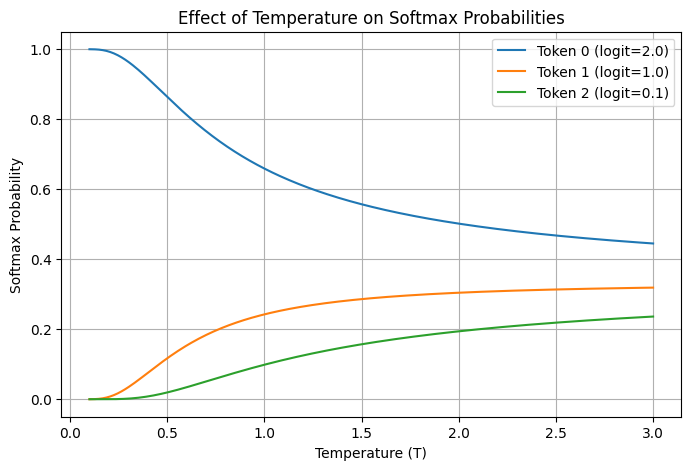

T=0.3: [0.96390178 0.03438623 0.00171199]
T=1.0: [0.65900114 0.24243297 0.09856589]
T=2.0: [0.50168776 0.30428901 0.19402324]


In [21]:
# @title Plot Probabilities vs Temperature
import matplotlib.pyplot as plt

temperatures = np.linspace(0.1, 3.0, 300)
probs = np.array([softmax_temp(logits, T) for T in temperatures])  # shape: (len(T), vocab=3)

plt.figure(figsize=(8, 5))
for i in range(probs.shape[1]):
    plt.plot(temperatures, probs[:, i], label=f"Token {i} (logit={logits[i]})")
plt.xlabel("Temperature (T)")
plt.ylabel("Softmax Probability")
plt.title("Effect of Temperature on Softmax Probabilities")
plt.grid(True)
plt.legend()
plt.show()

# Print your original examples
for T in [0.3, 1.0, 2.0]:
    print(f"T={T}: {softmax_temp(logits, T)}")




### 🔀 Entropy: Measuring Uncertainty

Entropy quantifies unpredictability:

$$
H(P) = -\sum_i P_i \log_2 P_i
$$

- Low $H$ → confident, stable predictions  
- High $H$ → uncertain, diverse outputs


In [6]:
import math

def entropy(p): return -sum(pi * math.log(pi, 2) for pi in p)

print("Entropy([0.9, 0.1]) =", entropy([0.9, 0.1]))
print("Entropy([0.5, 0.5]) =", entropy([0.5, 0.5]))

Entropy([0.9, 0.1]) = 0.4689955935892812
Entropy([0.5, 0.5]) = 1.0


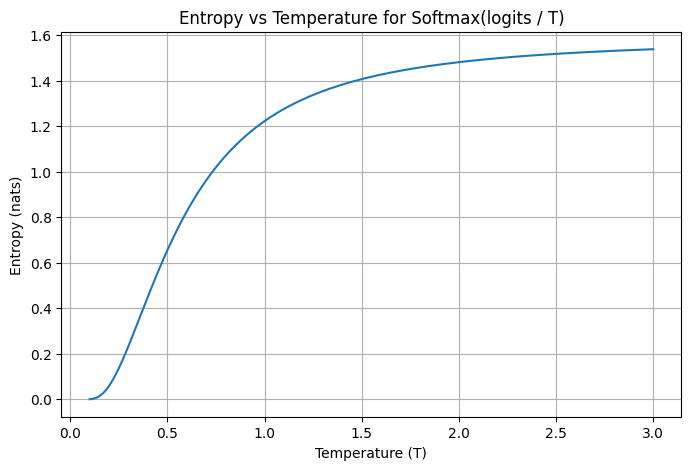

In [18]:
# @title Plot Entropy vs Temperature
entropies = np.array([entropy(p) for p in probs])

plt.figure(figsize=(8, 5))
plt.plot(temperatures, entropies)
plt.xlabel("Temperature (T)")
plt.ylabel("Entropy (nats)")
plt.title("Entropy vs Temperature for Softmax(logits / T)")
plt.grid(True)
plt.show()


### 🧠 Prompt Patterns and Conditioning

Prompts provide *context* that reshapes token probabilities:

$$
P_\theta(x_t \mid x_{1:t-1}, \text{prompt})
$$

Common patterns include:
1. **Role prompts:** “You are a teacher explaining entropy.”  
2. **Example prompts:** “Q: ... A: ...”  
3. **Constraint prompts:** “Answer in three bullet points.”



### 🧩 Concept Check — Prompt Conditioning

**Question:**  
How do prompts change a model’s behavior?

*(Hint: think in terms of conditional probability — what changes in $P_\theta(x_t \mid x_{1:t-1}, \text{prompt})$?)*


In [ ]:
# @title 💡 Show Suggested Answer
# Prompts alter the **conditioning context** the model uses when generating text.
# They effectively change the conditional probability distribution:
#     P(x_t | x_{1:t-1}, prompt)
# making the model sample from a distribution consistent with the prompt's tone, role, or constraints.


---

## 🎨 Prompt Engineering: Practical Patterns

Now that we understand how prompts condition outputs, let's learn some **systematic patterns** for writing effective prompts.

**Why this matters:** You'll write prompts throughout this course. Learning these patterns early will make all your work better.


### Pattern 1: Role-Playing Prompts

**What it is:** Tell the model to act as a specific person or role.

**Example:**
```
"You are a helpful teacher explaining concepts to beginners."
```

**Why it works:** The model adjusts its language and style to match the role.

**Try it:** Compare outputs with and without a role prompt.


In [7]:
# @title Example: Role-playing prompt
from openai import OpenAI
client = OpenAI()

question = "What is entropy?"

# Without role
response1 = client.responses.create(
    model="gpt-4o-mini",
    input=question,
)

# With role
response2 = client.responses.create(
    model="gpt-4o-mini",
    input=question,
    instructions="You are a helpful teacher explaining concepts to beginners."
)

print("Without role:")
display(Markdown(response1.output_text[:500] + "..."))
print("\nWith role:")
display(Markdown(response2.output_text[:500] + "..."))


Without role:


Entropy is a concept that appears in various fields, including thermodynamics, information theory, and statistical mechanics, but it generally refers to the measure of disorder or randomness in a system.

### In Thermodynamics:
- **Definition**: Entropy quantifies the amount of energy in a system that is unavailable to do work. It represents the degree of disorder or randomness in the particles of a substance.
- **Second Law of Thermodynamics**: This law states that in an isolated system, entrop...


With role:


Entropy is a concept that comes from both physics and information theory, and it generally refers to the measure of disorder or randomness in a system.

### In Thermodynamics:
1. **Disorder**: Entropy measures how spread out or disordered the energy in a system is. Higher entropy means more disorder and less usable energy.
2. **Second Law of Thermodynamics**: This law states that in an isolated system, the total entropy can never decrease over time. It tends to increase, which means systems natu...

### Pattern 2: Few-Shot Examples (In-Context Learning)

**What it is:** Show the model 1-2 examples of the task before asking it to do it.

**Example:**
```
Q: What is 2+2?
A: 4

Q: What is 3+5?
A: 8

Q: What is 7+9?
A:
```

**Why it works:** The model learns the pattern from examples and applies it.

**When to use:** When you want consistent formatting or a specific style.


In [8]:
# @title Example: Few-shot prompt
# Without examples
prompt1 = "Classify this sentiment: 'I love this course!'"

# With examples
prompt2 = """Classify the sentiment of each sentence.

Sentence: 'This is great!'
Sentiment: positive

Sentence: 'I hate this.'
Sentiment: negative

Sentence: 'I love this course!'
Sentiment:"""

response1 = client.responses.create(
    model="gpt-4o-mini",
    input=prompt1,
)

response2 = client.responses.create(
    model="gpt-4o-mini",
    input=prompt2
)

print("Without examples:")
display(response1.output_text)
print("\nWith examples:")
display(response2.output_text)


Without examples:


'The sentiment is positive.'


With examples:


'Sentiment: positive'

### Pattern 3: Chain-of-Thought Reasoning

**What it is:** Ask the model to "think step by step" or "show your work."

**Example:**
```
"Solve this step by step: If a train travels 60 miles in 2 hours, how fast is it going?"
```

**Why it works:** Breaking down reasoning often leads to more accurate answers.

**When to use:** For math problems, logic puzzles, or complex reasoning tasks.


In [9]:
# @title Example: Chain-of-thought prompt
question = "If a train travels 60 miles in 2 hours, how fast is it going?"

# Without chain-of-thought
response1 = client.responses.create(
    model="gpt-4o-mini",
    input=question,
)

# With chain-of-thought
response2 = client.responses.create(
    model="gpt-4o-mini",
    input=f"Solve this step by step: {question}"
)

print("Without chain-of-thought:")
display(Markdown(response1.output_text))
print("\nWith chain-of-thought:")
display(Markdown(response2.output_text))


Without chain-of-thought:


To find the speed of the train, you can use the formula:

\[
\text{Speed} = \frac{\text{Distance}}{\text{Time}}
\]

In this case, the distance is 60 miles and the time is 2 hours.

\[
\text{Speed} = \frac{60 \text{ miles}}{2 \text{ hours}} = 30 \text{ miles per hour}
\]

So, the train is traveling at a speed of 30 miles per hour.


With chain-of-thought:


To find the speed of the train, you can use the formula for speed:

\[
\text{Speed} = \frac{\text{Distance}}{\text{Time}}
\]

### Step 1: Identify the Distance and Time
- Distance = 60 miles
- Time = 2 hours

### Step 2: Plug in the Values
Now substitute the values into the formula:

\[
\text{Speed} = \frac{60 \text{ miles}}{2 \text{ hours}}
\]

### Step 3: Perform the Calculation
Now, divide 60 by 2:

\[
\text{Speed} = 30 \text{ miles per hour}
\]

### Conclusion
The train is traveling at a speed of **30 miles per hour**.

### Pattern 4: Structured Output

**What it is:** Ask for a specific format (bullets, numbered list, JSON, etc.).

**Example:**
```
"Explain entropy in exactly 3 bullet points."
```

**Why it works:** Constraints help the model focus and produce more usable output.

**When to use:** When you need consistent formatting for downstream processing.


### 💡 Practical Tips

**Be specific vs vague:**
- ❌ Vague: "Explain AI"
- ✅ Specific: "Explain what artificial intelligence is in 2-3 sentences for a beginner"

**Use system messages for roles:**
- System messages are better for setting the model's "personality" or role
- User messages are for the actual question or task

**Show, don't just tell:**
- Instead of "be concise," show an example: "Answer like this: 'AI is...'"


### ⚠️ Common Mistakes

**1. Overly long prompts:**
- Longer prompts cost more tokens (money)
- Very long prompts can confuse the model
- **Tip:** Keep it focused. Remove unnecessary words.
- **Example:** "Explain AI" (2 words) vs "Explain what artificial intelligence is in 2-3 sentences for a beginner" (12 words) - both work, but the second is more specific without being too long

**2. Unclear instructions:**
- ❌ "Make it better"
- ✅ "Make it shorter and use simpler words"

**3. Mixing instructions with examples:**
- Keep instructions clear and separate from examples
- Use structure: Instructions → Examples → Task

**4. Forgetting to specify format:**
- If you need bullets, say "in bullet points"
- If you need a number, say "give me a number"


### 🧪 Quick Exercise: Compare Prompts

Try the same question with different prompt styles and see how the output changes!


In [12]:
# @title Try different prompt styles
question = "What is probability?"

# Style 1: Basic
prompt1 = question

# Style 2: With role
prompt2 = f"You are a teacher. {question}"

# Style 3: With structure
prompt3 = f"{question} Answer in 2 bullet points."

# Try one and compare!
response = client.responses.create(
    model="gpt-4o-mini",
    input=prompt2
)
display(Markdown(response.output_text))


Probability is a branch of mathematics that deals with the likelihood or chance of different outcomes occurring in uncertain situations. It quantifies how likely an event is to happen, usually expressed as a number between 0 and 1. 

- **0** means that the event will not happen.
- **1** means that the event will definitely happen.

For example, if you flip a fair coin, the probability of getting heads is 0.5 (or 50%) because there are two equally likely outcomes: heads or tails.

Probability can be calculated using the formula:

\[
P(A) = \frac{\text{Number of favorable outcomes}}{\text{Total number of possible outcomes}}
\]

where \( P(A) \) is the probability of event \( A \). 

In summary, probability helps us understand and predict the likelihood of various events based on known data and assumptions.

---

## 🔄 Prompt Engineering + Temperature: Working Together

Now let's see how **prompt engineering** and **temperature** work together in real tasks.


### Example: Creative Writing vs Factual QA

**Task 1: Creative Writing** (benefits from higher temperature)
- Goal: Write a creative story
- Temperature: Higher (e.g., 0.8-1.2) for variety
- Prompt: "Write a short creative story about a robot learning to paint."

**Task 2: Factual QA** (benefits from lower temperature)
- Goal: Answer a factual question accurately
- Temperature: Lower (e.g., 0.1-0.3) for consistency
- Prompt: "What is the capital of France? Answer with just the city name."


In [13]:
# @title Compare: Low vs High Temperature for Different Tasks

# Factual question - try low temperature
factual_prompt = "What is the capital of France? Answer with just the city name."

response_low = client.responses.create(
    model="gpt-4o-mini",
    input=factual_prompt,
    temperature=0.2
)

# Creative task - try higher temperature
creative_prompt = "Write one sentence about a robot learning to paint."

response_high = client.responses.create(
    model="gpt-4o-mini",
    input=creative_prompt,
    temperature=1.0
)

display(Markdown("Factual (T=0.2):" + response_low.output_text))
display(Markdown("\nCreative (T=1.0):" + response_high.output_text))


Factual (T=0.2):Paris


Creative (T=1.0):A curious robot, equipped with sensors and algorithms, meticulously studied the strokes of famous artists to create its own vibrant masterpiece on canvas.

### When to Use Deterministic vs Stochastic Settings

**Deterministic (low temperature, ~0.0-0.3):**
- ✅ Factual questions that need consistent answers
- ✅ Code generation (you want the same code each time)
- ✅ Data extraction tasks
- ✅ When debugging (same input → same output)

**Stochastic (higher temperature, ~0.7-1.5):**
- ✅ Creative writing
- ✅ Brainstorming ideas
- ✅ Generating multiple options
- ✅ When you want variety

**Rule of thumb:** Start with low temperature (0.2-0.3) for most tasks. Increase only if you need creativity.


### 🧩 Concept Check — Prompt Engineering

**Question:**  
If you want the model to give you a consistent, factual answer, what temperature should you use and what prompt pattern might help?

**Think about:**
- Temperature setting (low or high?)
- Prompt pattern (role? structure? examples?)


### 🧪 Bridge to Lab 2 — Measuring Diversity

In Lab 2, you will vary `temperature` and measure diversity:

$$
\text{Diversity Index} = \frac{\text{unique tokens}}{\text{total tokens}}
$$

You'll test how higher temperature increases diversity but may reduce accuracy.

**Connection to prompt engineering:** The same prompt can produce very different outputs at different temperatures. This is why choosing the right temperature matters!


### 💭 Reflection — Connecting Theory to Design

- When might you prefer **low entropy** (predictable) text?
- When might you prefer **high entropy** (creative) text?
- How does this relate to *reliability vs. creativity* in real-world AI systems?
- **New:** Which prompt pattern would you use for a customer service chatbot? Why?
- **New:** If you're building a system that needs consistent answers, what temperature and prompt style would you choose?



<details>
<summary>🧑‍🏫 Instructor Notes</summary>

**Day 1 Focus:**  
- Emphasize intuition behind $P(x_t | x_{1:t-1})$.  
- Use visual examples (like bar charts) to show shifting probabilities.  

**Day 2 Focus:**  
- Encourage students to experiment interactively with temperature.  
- Discuss connections between entropy, creativity, and trustworthiness.  
- **New:** Prompt engineering patterns - have students try different patterns and compare outputs.
- **New:** Show how temperature and prompt engineering work together (factual vs creative tasks).

**Extension Ideas:**  
- Demonstrate `top_p` sampling for comparison.  
- Optional: short visualization of entropy vs. creativity using matplotlib.
- Have students write their own prompts using different patterns and compare results.
</details>
